In [ ]:
# This cell performs an enhanced error comparison of SVD, QR, and RRQR decomposition methods.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.linalg as la


num_trials = 50
m, n, k = 100, 100, 30

frobenius_errors_svd = []
frobenius_errors_qr = []
frobenius_errors_rrqr = []

spectral_errors_svd = []
spectral_errors_qr = []
spectral_errors_rrqr = []

for _ in range(num_trials):
    A = np.random.randn(m, n)

    # SVD approximation
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    Uk = U[:, :k]
    Sk = np.diag(S[:k])
    Vk = Vt[:k, :]
    A_svd = Uk @ Sk @ Vk
    frobenius_errors_svd.append(np.linalg.norm(A - A_svd, 'fro'))
    spectral_errors_svd.append(np.linalg.norm(A - A_svd, 2))

    # QR-based approximation
    B = A[:, :k]
    Q, R = la.qr(B)
    A_qr = Q @ Q.T @ A
    frobenius_errors_qr.append(np.linalg.norm(A - A_qr, 'fro'))
    spectral_errors_qr.append(np.linalg.norm(A - A_qr, 2))

    # RRQR approximation
    Q_rrqr, R_rrqr, P = la.qr(A, pivoting=True)
    Qk_rrqr = Q_rrqr[:, :k]
    A_rrqr = Qk_rrqr @ Qk_rrqr.T @ A
    frobenius_errors_rrqr.append(np.linalg.norm(A - A_rrqr, 'fro'))
    spectral_errors_rrqr.append(np.linalg.norm(A - A_rrqr, 2))

df_fro = pd.DataFrame({
    'SVD': frobenius_errors_svd,
    'QR': frobenius_errors_qr,
    'RRQR': frobenius_errors_rrqr
})

df_spec = pd.DataFrame({
    'SVD': spectral_errors_svd,
    'QR': spectral_errors_qr,
    'RRQR': spectral_errors_rrqr
})

Completed 50 trials for error comparison.


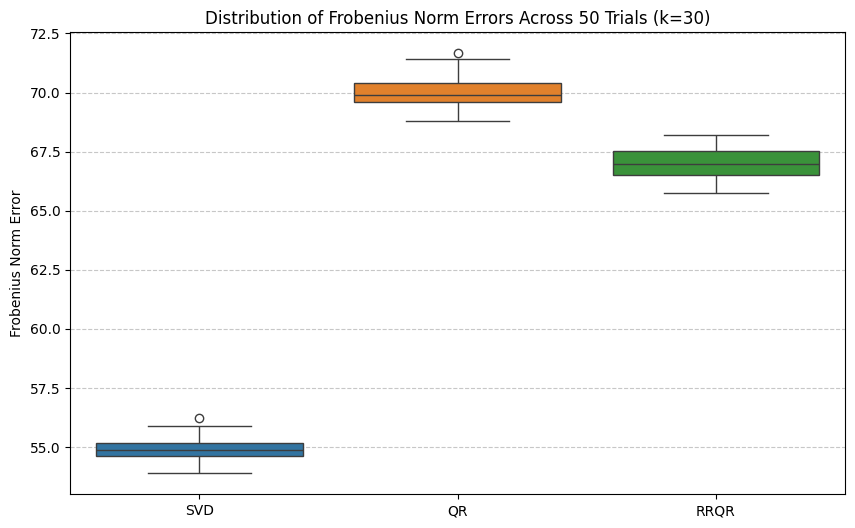

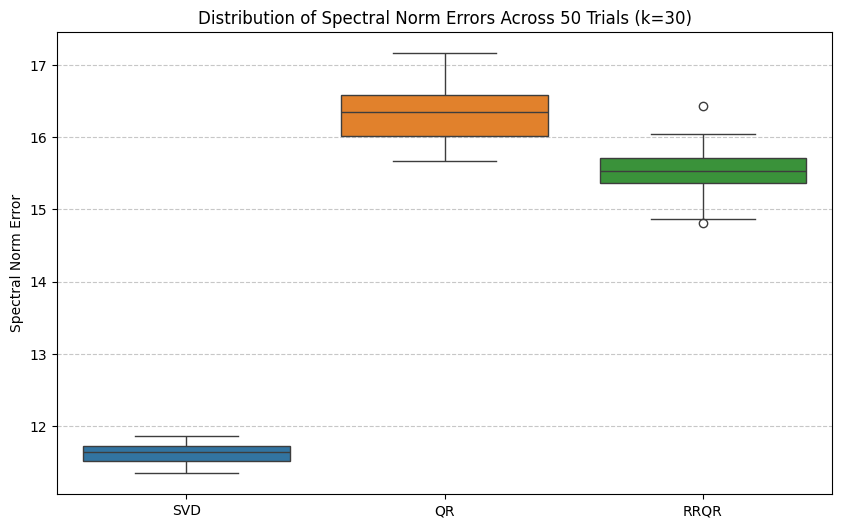

In [ ]:
# This cell visualizes the distribution of Frobenius and Spectral Norm Errors using box plots.
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_fro)
plt.ylabel('Frobenius Norm Error')
plt.title(f'Distribution of Frobenius Norm Errors Across {num_trials} Trials (k={k})')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_spec)
plt.ylabel('Spectral Norm Error')
plt.title(f'Distribution of Spectral Norm Errors Across {num_trials} Trials (k={k})')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_4643/2145197499.py:178: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


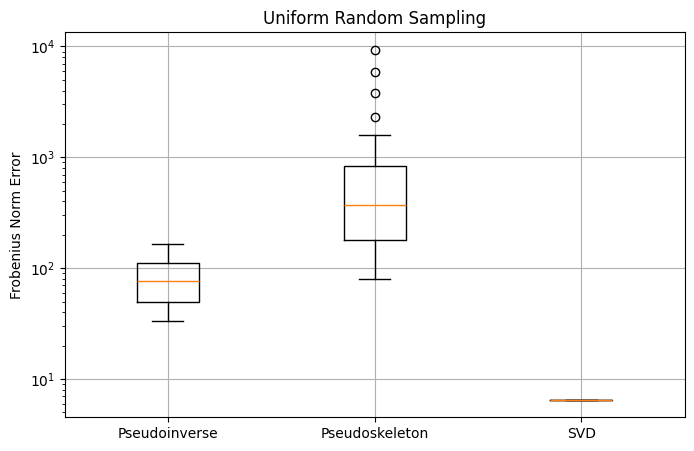

/tmp/ipykernel_4643/2145197499.py:196: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


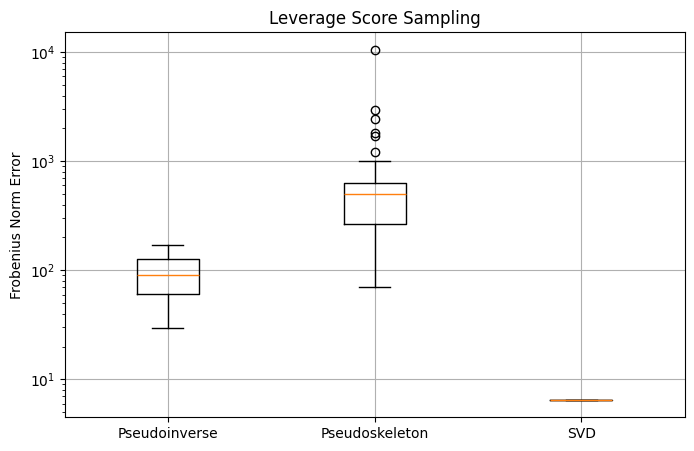

/tmp/ipykernel_4643/2145197499.py:214: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


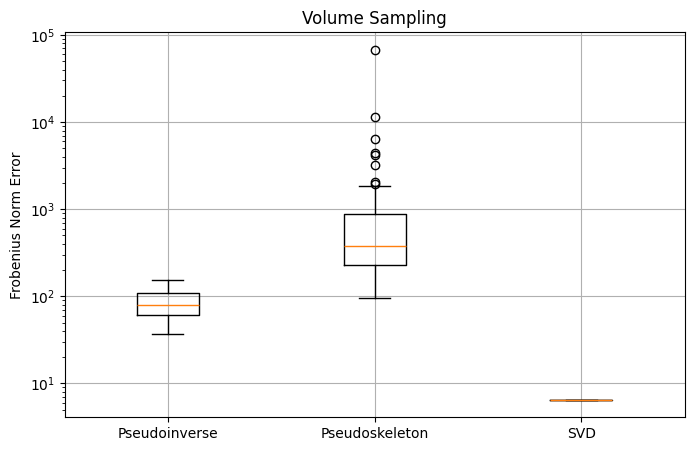

In [ ]:
# This cell implements and compares CUR approximation methods (Pseudoinverse and Pseudoskeleton) with SVD, using different sampling techniques.


np.random.seed(42)

m, n = 150, 150
true_rank = 20

U_true = np.random.randn(m, true_rank)
V_true = np.random.randn(true_rank, n)

A_low = U_true @ V_true
noise = 0.05 * np.random.randn(m, n)

A = A_low + noise

def truncated_svd(A, k):
    U, S, Vt = la.svd(A, full_matrices=False)
    return U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

def uniform_sampling(A, c):
    cols = np.random.choice(A.shape[1], c, replace=False)
    rows = np.random.choice(A.shape[0], c, replace=False)
    return rows, cols

def leverage_sampling(A, c):

    U, S, Vt = la.svd(A, full_matrices=False)

    Vk = Vt[:c, :]
    Uk = U[:, :c]

    col_scores = np.sum(Vk**2, axis=0)
    row_scores = np.sum(Uk**2, axis=1)

    col_probs = col_scores / np.sum(col_scores)
    row_probs = row_scores / np.sum(row_scores)

    cols = np.random.choice(A.shape[1], c,
                            replace=False, p=col_probs)

    rows = np.random.choice(A.shape[0], c,
                            replace=False, p=row_probs)

    return rows, cols

def volume_sampling(A, c):

    col_norms = np.linalg.norm(A, axis=0)**2
    row_norms = np.linalg.norm(A, axis=1)**2

    col_probs = col_norms / np.sum(col_norms)
    row_probs = row_norms / np.sum(row_norms)

    cols = np.random.choice(A.shape[1], c,
                            replace=False, p=col_probs)

    rows = np.random.choice(A.shape[0], c,
                            replace=False, p=row_probs)

    return rows, cols

def cur_approximation(A, rows, cols, method='pinv'):

    C = A[:, cols]
    R = A[rows, :]
    W = A[np.ix_(rows, cols)]

    if method == 'pinv':
        U = la.pinv(C) @ A @ la.pinv(R)

    elif method == 'skeleton':
        U = la.pinv(W)

    else:
        raise ValueError("Unknown method")

    return C @ U @ R

k = 20
trials = 50

uniform_pinv = []
uniform_skel = []
uniform_svd = []

lev_pinv = []
lev_skel = []
lev_svd = []

vol_pinv = []
vol_skel = []
vol_svd = []

for _ in range(trials):

    A_svd = truncated_svd(A, k)
    svd_error = np.linalg.norm(A - A_svd, 'fro')

    # Uniform sampling
    rows, cols = uniform_sampling(A, k)
    A_pinv = cur_approximation(A, rows, cols, 'pinv')
    A_skel = cur_approximation(A, rows, cols, 'skeleton')

    uniform_pinv.append(np.linalg.norm(A - A_pinv, 'fro'))
    uniform_skel.append(np.linalg.norm(A - A_skel, 'fro'))
    uniform_svd.append(svd_error)

    # Leverage sampling
    rows, cols = leverage_sampling(A, k)
    A_pinv = cur_approximation(A, rows, cols, 'pinv')
    A_skel = cur_approximation(A, rows, cols, 'skeleton')

    lev_pinv.append(np.linalg.norm(A - A_pinv, 'fro'))
    lev_skel.append(np.linalg.norm(A - A_skel, 'fro'))
    lev_svd.append(svd_error)

    # Volume sampling
    rows, cols = volume_sampling(A, k)
    A_pinv = cur_approximation(A, rows, cols, 'pinv')
    A_skel = cur_approximation(A, rows, cols, 'skeleton')

    vol_pinv.append(np.linalg.norm(A - A_pinv, 'fro'))
    vol_skel.append(np.linalg.norm(A - A_skel, 'fro'))
    vol_svd.append(svd_error)

plt.figure(figsize=(8,5))
plt.boxplot(
    [uniform_pinv, uniform_skel, uniform_svd],
    labels=['Pseudoinverse', 'Pseudoskeleton', 'SVD']
)
plt.ylabel('Frobenius Norm Error')
plt.title('Uniform Random Sampling')
plt.grid(True)
plt.yscale('log')
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(
    [lev_pinv, lev_skel, lev_svd],
    labels=['Pseudoinverse', 'Pseudoskeleton', 'SVD']
)
plt.ylabel('Frobenius Norm Error')
plt.title('Leverage Score Sampling')
plt.grid(True)
plt.yscale('log')
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(
    [vol_pinv, vol_skel, vol_svd],
    labels=['Pseudoinverse', 'Pseudoskeleton', 'SVD']
)
plt.ylabel('Frobenius Norm Error')
plt.title('Volume Sampling')
plt.grid(True)
plt.yscale('log')
plt.show()

/tmp/ipykernel_13300/254536960.py:101: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


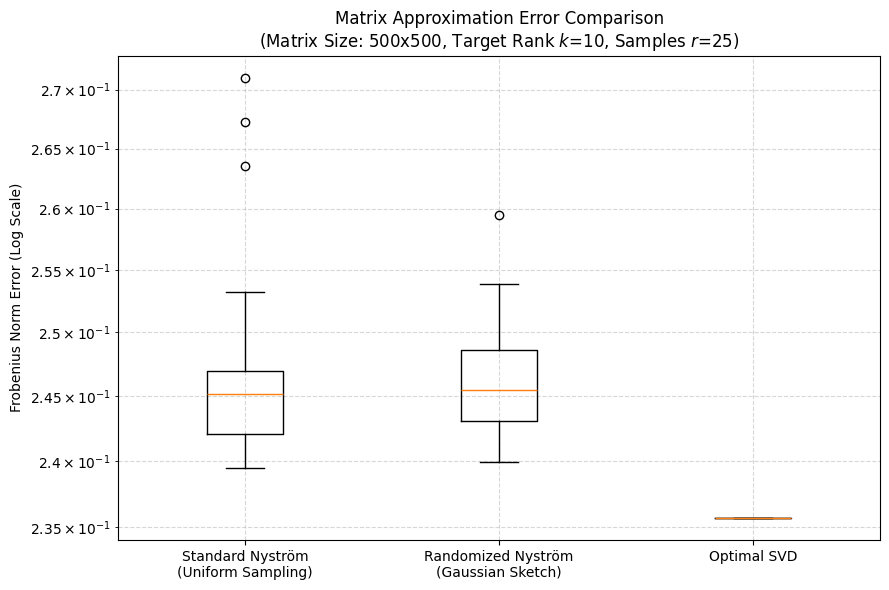

In [ ]:
# This cell compares Standard Nystrom (uniform sampling) and Randomized Nystrom (Gaussian sketch) approximations with optimal SVD.

def generate_psd_matrix(n, rank_eff, decay_rate=0.5):
    Q, _ = la.qr(np.random.randn(n, n))
    eigenvalues = np.exp(-decay_rate * np.arange(n))
    eigenvalues = np.maximum(eigenvalues, 1e-12)
    A = Q @ np.diag(eigenvalues) @ Q.T
    return A

def truncated_svd(A, k):
    U, s, Vt = la.svd(A, full_matrices=False)
    U_k = U[:, :k]
    s_k = s[:k]
    Vt_k = Vt[:k, :]
    return U_k @ np.diag(s_k) @ Vt_k

def standard_nystrom(A, r, k):
    n = A.shape[0]
    idx = np.random.choice(n, size=r, replace=False)
    C = A[:, idx]
    W = A[np.ix_(idx, idx)]

    W_pinv = la.pinv(W)

    A_hat = C @ W_pinv @ C.T

    U_h, s_h, _ = la.svd(A_hat, full_matrices=False)
    return U_h[:, :k] @ np.diag(s_h[:k]) @ U_h[:, :k].T

def randomized_nystrom(A, r, k):
    n = A.shape[0]
    Omega = np.random.randn(n, r)
    Y = A @ Omega

    Core = Omega.T @ Y
    Core_pinv = la.pinv(Core)

    A_hat = Y @ Core_pinv @ Y.T

    U_h, s_h, _ = la.svd(A_hat, full_matrices=False)
    return U_h[:, :k] @ np.diag(s_h[:k]) @ U_h[:, :k].T

n = 500
k = 10
r = 25
num_trials = 50

A = generate_psd_matrix(n, rank_eff=k, decay_rate=0.2)

A_k_svd = truncated_svd(A, k)
svd_error = la.norm(A - A_k_svd, 'fro')

errors_standard = []
errors_randomized = []
errors_svd = [svd_error] * num_trials

for trial in range(num_trials):
    A_hat_std = standard_nystrom(A, r, k)
    err_std = la.norm(A - A_hat_std, 'fro')
    errors_standard.append(err_std)

    A_hat_rand = randomized_nystrom(A, r, k)
    err_rand = la.norm(A - A_hat_rand, 'fro')
    errors_randomized.append(err_rand)

plt.figure(figsize=(9, 6))
data = [errors_standard, errors_randomized, errors_svd]
labels = ['Standard Nyström\n(Uniform Sampling)', 'Randomized Nyström\n(Gaussian Sketch)', 'Optimal SVD']

plt.boxplot(data, labels=labels)
plt.yscale('log')
plt.ylabel('Frobenius Norm Error (Log Scale)')
plt.title(f'Matrix Approximation Error Comparison\n(Matrix Size: {n}x{n}, Target Rank $k$={k}, Samples $r$={r})')
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

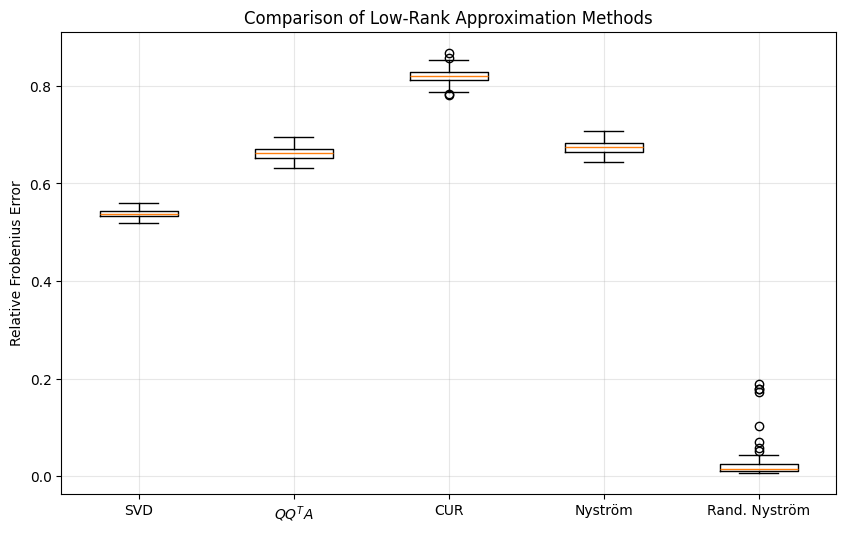

In [ ]:
# This cell compares five low-rank approximation methods: Truncated SVD, QQ^T, CUR, Classical Nyström, and Randomized Nyström.

np.random.seed(42)

n = 300
true_rank = 20
k = 10
trials = 50

svd_errors = []
qqt_errors = []
cur_errors = []
nystrom_errors = []
rand_nystrom_errors = []

for t in range(trials):

    U = np.random.randn(n, true_rank)
    A = U @ U.T
    A += 0.01*np.random.randn(n,n)
    A = (A + A.T)/2

    # Truncated SVD
    U_svd, S_svd, Vt_svd = np.linalg.svd(A, full_matrices=False)
    A_svd = (
        U_svd[:, :k]
        @ np.diag(S_svd[:k])
        @ Vt_svd[:k, :]
    )
    svd_errors.append(
        np.linalg.norm(A - A_svd, 'fro') / np.linalg.norm(A,'fro')
    )

    # QQ^T Approximation
    Omega = np.random.randn(n, k)
    Y = A @ Omega
    Q, _ = np.linalg.qr(Y)
    A_qqt = Q @ Q.T @ A
    qqt_errors.append(
        np.linalg.norm(A - A_qqt,'fro') / np.linalg.norm(A,'fro')
    )

    # CUR
    cols = np.random.choice(n, k, replace=False)
    rows = np.random.choice(n, k, replace=False)
    C = A[:, cols]
    R = A[rows, :]
    Ucur = la.pinv(C) @ A @ la.pinv(R)
    A_cur = C @ Ucur @ R
    cur_errors.append(
        np.linalg.norm(A - A_cur,'fro') / np.linalg.norm(A,'fro')
    )

    # Classical Nyström
    idx = np.random.choice(n, k, replace=False)
    Cn = A[:, idx]
    W = A[np.ix_(idx, idx)]
    A_nys = Cn @ la.pinv(W) @ Cn.T
    nystrom_errors.append(
        np.linalg.norm(A - A_nys,'fro') / np.linalg.norm(A,'fro')
    )

    # Randomized Nyström
    p = 10
    Omega = np.random.randn(n, k+p)
    Y = A @ Omega
    Q, _ = np.linalg.qr(Y)
    B = Q.T @ A @ Q
    A_rand_nys = Q @ B @ Q.T
    rand_nystrom_errors.append(
        np.linalg.norm(A - A_rand_nys,'fro') / np.linalg.norm(A,'fro')
    )

plt.figure(figsize=(10,6))
plt.boxplot([
    svd_errors,
    qqt_errors,
    cur_errors,
    nystrom_errors,
    rand_nystrom_errors
])
plt.xticks(
    [1,2,3,4,5],
    [
        "SVD",
        r"$QQ^TA$",
        "CUR",
        "Nyström",
        "Rand. Nyström"
    ]
)
plt.ylabel("Relative Frobenius Error")
plt.title(
    "Comparison of Low-Rank Approximation Methods"
)
plt.grid(alpha=0.3)
plt.show()

<>:58: SyntaxWarning: invalid escape sequence '\O'
<>:58: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_3997/1040299636.py:58: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel('Number of Samples / Columns in $\Omega$ (m)', fontsize=12)


Running Monte Carlo simulation. This might take a few seconds...


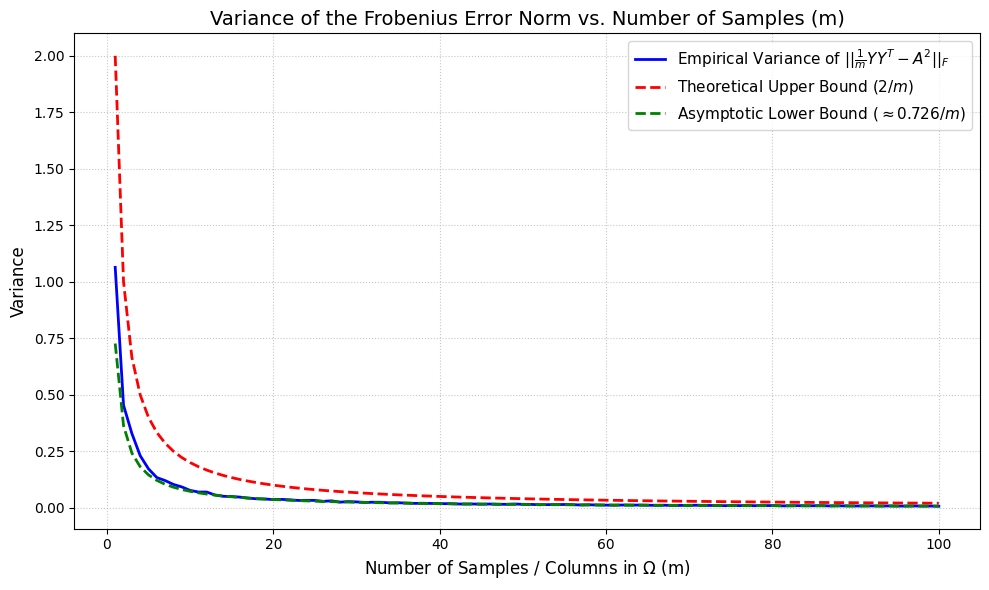

In [ ]:
# This cell conducts a Monte Carlo simulation to analyze the variance of the Frobenius error for a rank-1 SPD matrix.

n = 10
m_values = np.arange(1, 101)
num_trials = 2000

empirical_variances = []

u_vec = np.random.randn(n, 1)
u_vec = u_vec / np.linalg.norm(u_vec)
A = u_vec @ u_vec.T
A2 = A @ A
for m in m_values:
    norms = np.zeros(num_trials)

    for i in range(num_trials):
        Omega = np.random.randn(n, m)
        Y = A @ Omega
        estimator = (1 / m) * (Y @ Y.T)
        error_matrix = estimator - A2
        error_norm = np.linalg.norm(error_matrix, 'fro')
        norms[i] = error_norm

    empirical_variances.append(np.var(norms))

upper_bound = 2 / m_values
lower_bound = (2 / m_values) * (1 - 2 / np.pi)

plt.figure(figsize=(10, 6))

plt.plot(m_values, empirical_variances, label=r'Empirical Variance of $|| \frac{1}{m}YY^T - A^2 ||_F$',
         color='blue', linewidth=2)
plt.plot(m_values, upper_bound, label=r'Theoretical Upper Bound ($2/m$)',
         color='red', linestyle='--', linewidth=2)
plt.plot(m_values, lower_bound, label=r'Asymptotic Lower Bound ($\approx 0.726/m$)',
         color='green', linestyle='--', linewidth=2)

plt.title('Variance of the Frobenius Error Norm vs. Number of Samples (m)', fontsize=14)
plt.xlabel('Number of Samples / Columns in $\Omega$ (m)', fontsize=12)
plt.ylabel('Variance', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/figure_2_2.pdf'

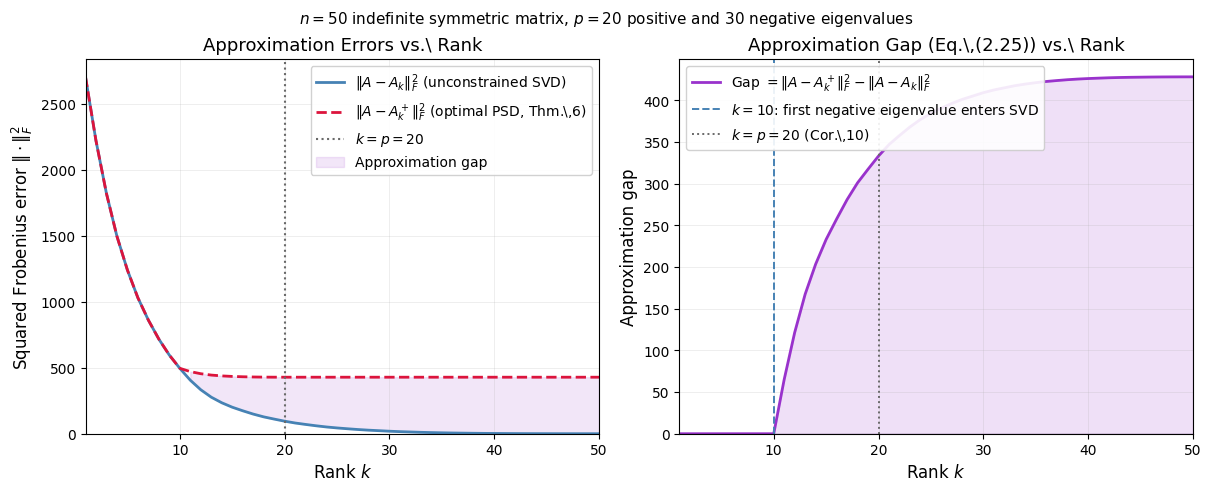

In [1]:
# This cell generates a symmetric matrix A with a specified number of positive and negative eigenvalues. It then calculates and plots the Frobenius norm errors for unconstrained SVD approximation and optimal PSD approximation, as well as the approximation gap between them, to illustrate Theorem 9. The results are saved as PDF and PNG figures.
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 50
n_pos = 20
n_neg = 30
lambda_pos = np.array([
    25.0, 22.0, 20.0, 18.0, 16.0, 14.5, 13.0, 12.0, 11.0, 10.0,
     5.0,  4.0,  3.2,  2.5,  2.0,  1.6,  1.3,  1.0,  0.7,  0.4
])
lambda_neg = -np.array([
    9.5, 8.5, 7.5, 6.5, 5.8, 5.2, 4.6, 4.1, 3.7, 3.3,
    3.0, 2.7, 2.4, 2.2, 2.0, 1.8, 1.6, 1.4, 1.2, 1.05,
    0.9, 0.78, 0.67, 0.57, 0.48, 0.40, 0.33, 0.26, 0.19, 0.12
])
all_eigenvalues = np.concatenate([lambda_pos,
                                  np.sort(lambda_neg)[::-1]])
G = np.random.randn(n, n)
Q, _ = np.linalg.qr(G)
A = Q @ np.diag(all_eigenvalues) @ Q.T
A = 0.5 * (A + A.T)
sigma = np.sort(np.abs(all_eigenvalues))[::-1]
lam_pos_sorted = np.sort(lambda_pos)[::-1]
frobenius_sq = float(np.sum(all_eigenvalues**2))
cumsum_sigma_sq  = np.concatenate([[0.0], np.cumsum(sigma**2)])
cumsum_lambda_sq = np.concatenate([[0.0], np.cumsum(lam_pos_sorted**2)])
ranks = np.arange(1, n + 1)
err_svd = frobenius_sq - cumsum_sigma_sq[1:]
err_psd = np.array([
    frobenius_sq - cumsum_lambda_sq[min(k, n_pos)]
    for k in ranks
])
gap = err_psd - err_svd
assert np.all(gap >= -1e-10), "Gap should be non-negative by Theorem 9"
k_threshold = 10
assert np.allclose(gap[:k_threshold], 0, atol=1e-10), \
    "Gap should be zero while Ak >= 0"
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
ax = axes[0]
ax.plot(ranks, err_svd,
        color='steelblue', linewidth=2.0,
        label=r'$||A - A_k||_F^2$ (unconstrained SVD)')
ax.plot(ranks, err_psd,
        color='crimson', linewidth=2.0, linestyle='--',
        label=r'$||A - A_k^+||_F^2$ (optimal PSD, Thm.\,6)')
ax.axvline(x=n_pos, color='dimgray', linestyle=':', linewidth=1.5,
           label=fr'$k = p = {n_pos}$')
ax.fill_between(ranks, err_svd, err_psd,
                where=(gap > 1e-10),
                alpha=0.12, color='darkorchid',
                label='Approximation gap')
ax.set_xlabel(r'Rank $k$', fontsize=12)
ax.set_ylabel(r'Squared Frobenius error $||\cdot||_F^2$', fontsize=12)
ax.set_title(r'Approximation Errors vs.\ Rank', fontsize=13)
ax.legend(fontsize=10, framealpha=0.9, loc='upper right')
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.set_xlim(1, n)
ax.set_ylim(bottom=0)
ax2 = axes[1]
ax2.plot(ranks, gap,
         color='darkorchid', linewidth=2.0,
         label=r'Gap $= ||A-A_k^+||_F^2 - ||A-A_k||_F^2$')
ax2.fill_between(ranks, gap, alpha=0.15, color='darkorchid')
ax2.axvline(x=k_threshold, color='steelblue', linestyle='--', linewidth=1.4,
            label=fr'$k = {k_threshold}$: first negative eigenvalue enters SVD')
ax2.axvline(x=n_pos, color='dimgray', linestyle=':', linewidth=1.4,
            label=fr'$k = p = {n_pos}$ (Cor.\,10)')
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_xlabel(r'Rank $k$', fontsize=12)
ax2.set_ylabel(r'Approximation gap', fontsize=12)
ax2.set_title(r'Approximation Gap (Eq.\,(2.25)) vs.\ Rank', fontsize=13)
ax2.legend(fontsize=10, framealpha=0.9, loc='upper left')
ax2.grid(True, alpha=0.3, linewidth=0.5)
ax2.set_xlim(1, n)
ax2.set_ylim(bottom=0)
fig.suptitle(
    r'$n = 50$ indefinite symmetric matrix, '
    fr'$p = {n_pos}$ positive and ${n_neg}$ negative eigenvalues',
    fontsize=11
)
plt.savefig('/mnt/user-data/outputs/figure_2_2.pdf', dpi=300, bbox_inches='tight')
plt.savefig('/mnt/user-data/outputs/figure_2_2.png', dpi=300, bbox_inches='tight')
print("Saved figure_2_2.pdf and figure_2_2.png")
plt.show()

In [ ]:
# This cell generates figures comparing randomized sketching for matrix approximation under different matrix properties.

RNG_SEED   = 42
NUM_TRIALS = 50
EPSILON    = 1e-2

plt.rcParams.update({
    "font.family":    "serif",
    "font.size":      11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 9,
    "figure.dpi":     150,
})

def random_orthogonal(n, rng):
    Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
    return Q

def make_projection(n, k, rng):
    Q   = random_orthogonal(n, rng)
    lam = np.array([1.0] * k + [0.0] * (n - k))
    return Q @ np.diag(lam) @ Q.T, lam

def make_spd(n, k, rng):
    Q   = random_orthogonal(n, rng)
    lam = np.array([float(k + 1 - i) for i in range(1, k + 1)] + [EPSILON] * (n - k))
    return Q @ np.diag(lam) @ Q.T, lam

def make_indefinite(n, k, rng):
    Q   = random_orthogonal(n, rng)
    kp  = k // 2;  kn = k - kp
    pos = [float(k + 1 - i) for i in range(1,      kp + 1)]
    neg = [-float(k + 1 - i) for i in range(kp + 1, k  + 1)]
    lam = np.array(pos + neg + [EPSILON] * (n - k))
    return Q @ np.diag(lam) @ Q.T, lam

def make_signed_projection(n, k, rng):
    Q   = random_orthogonal(n, rng)
    kp  = k // 2;  kn = k - kp
    lam = np.array([1.0] * kp + [-1.0] * kn + [0.0] * (n - k))
    return Q @ np.diag(lam) @ Q.T, lam

def estimator(A, m, rng):
    n     = A.shape[0]
    Omega = rng.standard_normal((n, m))
    Y     = A @ Omega
    return (Y @ Y.T) / m

def sq_frob(A, B):
    d = A - B
    return float(np.einsum("ij,ij->", d, d))

def run_trials(A, target, m, n_trials, rng):
    return np.array([sq_frob(estimator(A, m, rng), target) for _ in range(n_trials)])

def run_trials_original(A, target, m, n_trials, rng):
    return np.array([sq_frob(la.sqrtm(estimator(A, m, rng)), target) for _ in range(n_trials)])

def theory_rmse_projection(k, p):
    return np.sqrt(k * (k + 1) / (k + p))

def theory_rmse_general(lam, m):
    lam2 = lam ** 2
    return np.sqrt((np.dot(lam2, lam2) + np.sum(lam2) ** 2) / m)

def theory_rmse_A_signed(k, m):
    kn          = k - k // 2
    sign_bias   = 4.0 * kn
    return np.sqrt(k * (k + 1) / m + sign_bias)

def fig_rmse_vs_oversampling(n=200):
    print("Figure 4.1: RMSE vs oversampling …")
    k_list = [5, 10, 20]
    p_arr  = np.arange(0, 101)
    colors = ["#2166ac", "#d6604d", "#4dac26"]

    fig, ax = plt.subplots(figsize=(8, 5))
    trial_rng = np.random.default_rng(RNG_SEED)

    for k, col in zip(k_list, colors):
        A, _    = make_projection(n, k, rng=np.random.default_rng(RNG_SEED + k))
        A2_true = A @ A

        emp_mean = np.empty(len(p_arr))
        emp_sd   = np.empty(len(p_arr))

        for j, p in enumerate(p_arr):
            m            = k + p
            errs_sq      = run_trials(A, A2_true, m, NUM_TRIALS, trial_rng)
            mu           = np.mean(errs_sq)
            emp_mean[j]  = np.sqrt(mu)
            emp_sd[j]    = np.std(errs_sq) / (2 * np.sqrt(mu + 1e-30) * np.sqrt(NUM_TRIALS))

        theory = np.array([theory_rmse_projection(k, p) for p in p_arr])

        ax.plot(p_arr, theory,   color=col, lw=2.0, zorder=3, label=f"$k={k}$ (theory)")
        ax.plot(p_arr, emp_mean, color=col, lw=1.5, ls="--",  zorder=2, label=f"$k={k}$ (empirical)")
        ax.fill_between(p_arr, emp_mean - emp_sd, emp_mean + emp_sd,
                        alpha=0.15, color=col, zorder=1)

        print(f"  k={k} done")

    ax.set_xlabel("Oversampling parameter $p$")
    ax.set_ylabel("RMSE")
    ax.set_title(
        "Theoretical vs Empirical RMSE as a Function of Oversampling\n"
        rf"($n={n}$, rank-$k$ projection matrices, {NUM_TRIALS} trials)"
    )
    ax.legend(ncol=2, loc="upper right")
    ax.set_xlim(0, 100); ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    print("  → saved figures/rmse_vs_oversampling.pdf\n")

def fig_error_vs_rank(n=150, m_fixed=30):
    print("Figure 4.2: Error vs rank …")
    k_arr     = np.arange(2, m_fixed)
    trial_rng = np.random.default_rng(RNG_SEED)

    spd_emp    = np.empty(len(k_arr))
    spd_emp1   = np.empty(len(k_arr))
    ind_A2_emp = np.empty(len(k_arr))
    ind_A_emp  = np.empty(len(k_arr))

    for i, k in enumerate(k_arr):
        A_spd, _ = make_projection(n, k, rng=np.random.default_rng(RNG_SEED + k))
        spd_emp[i] = np.mean(np.sqrt(
            run_trials(A_spd, A_spd @ A_spd, m_fixed, NUM_TRIALS, trial_rng)
        ))
        spd_emp1[i] = np.mean(np.sqrt(
            run_trials_original(A_spd, A_spd, m_fixed, NUM_TRIALS, trial_rng)
        ))

        A_sgn, _ = make_signed_projection(n, k, rng=np.random.default_rng(RNG_SEED + k + 500))
        A2_sgn   = A_sgn @ A_sgn

        ind_A2_emp[i] = np.mean(np.sqrt(
            run_trials(A_sgn, A2_sgn, m_fixed, NUM_TRIALS, trial_rng)
        ))
        ind_A_emp[i] = np.mean(np.sqrt(
            run_trials_original(A_sgn, A_sgn,  m_fixed, NUM_TRIALS, trial_rng)
        ))

        if k % 5 == 0:
            print(f"  k={k} done")

    th_A2      = np.array([theory_rmse_projection(k, m_fixed - k) for k in k_arr])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.plot(k_arr, th_A2,   "b-",  lw=2.0, label="Theory  (Eq. 2.16)")
    ax.plot(k_arr, spd_emp, "b--", lw=1.5, marker="o", ms=4,
            label=r"Empirical  $(1/m)\mathbf{YY}^T$ vs $\mathbf{A}^2 = \mathbf{A}$")
    ax.plot(k_arr, spd_emp1, "r--", lw=1.5, marker="o", ms=4,
            label=r"Empirical  $\sqrt{(1/m)\mathbf{YY}^T}$ vs $\mathbf{A}$")
    ax.set_xlabel("Rank $k$")
    ax.set_ylabel("Mean Frobenius error")
    ax.set_title("SPD Projector  ($\lambda_i = +1$)")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(k_arr, th_A2,       "b-",  lw=2.0,
            label=r"Theory  $\mathbf{A}^2$ target  (same formula as left)")
    ax.plot(k_arr, ind_A2_emp,  "b--", lw=1.5, marker="o", ms=4,
            label=r"Empirical  $(1/m)\mathbf{YY}^T$ vs $\mathbf{A}^2$")
    ax.plot(k_arr, ind_A_emp,   "r--", lw=1.5, marker="s", ms=4,
            label=r"Empirical  $\sqrt{(1/m)\mathbf{YY}^T}$ vs $\mathbf{A}$  (sign bias)")

    ax.set_xlabel("Rank $k$")
    ax.set_title("Signed Projector  ($\lambda_i = \pm 1$,  same $|\lambda_i|$ as left)")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)

    y_max = max(ind_A_emp.max(), theory_rmse_A_signed(k_arr[-1], m_fixed)) * 1.08
    for ax in axes:
        ax.set_ylim(0, y_max)

    fig.suptitle(
        rf"Mean Frobenius Error vs Rank  ($n={n}$, $m={m_fixed}$, {NUM_TRIALS} trials)"
        "\nBlue: error estimating $\mathbf{A}^2$  ·  "
        "Red: error estimating $\mathbf{A}$ (irreducible sign-bias for indefinite matrices)",
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    print("  → saved figures/error_vs_rank.pdf\n")

def fig_rmse_heatmap(n=200):
    print("Figure 4.3: RMSE heatmap (may take ~2 min) …")
    k_arr     = np.arange(2, 26)
    p_arr     = np.arange(0, 51)
    trial_rng = np.random.default_rng(RNG_SEED)
    rmse_emp  = np.empty((len(k_arr), len(p_arr)))

    for i, k in enumerate(k_arr):
        A, _ = make_projection(n, k, rng=np.random.default_rng(RNG_SEED + k))
        A2   = A @ A
        for j, p in enumerate(p_arr):
            errs = run_trials(A, A2, k + p, NUM_TRIALS, trial_rng)
            rmse_emp[i, j] = np.sqrt(np.mean(errs))
        print(f"  k={k:2d} done")

    KK, PP      = np.meshgrid(k_arr, p_arr, indexing="ij")
    rmse_theory = np.sqrt(KK * (KK + 1) / (KK + PP + 1e-9))

    fig, ax = plt.subplots(figsize=(9, 6))
    im  = ax.pcolormesh(p_arr, k_arr, rmse_emp, shading="auto",
                        cmap="viridis_r", vmin=0, vmax=rmse_emp.max())
    plt.colorbar(im, ax=ax, pad=0.02, label="Empirical RMSE")

    cs = ax.contour(p_arr, k_arr, rmse_theory, levels=[0.5, 1.0, 1.5, 2.0, 3.0, 5.0],
                    colors="white", linewidths=1.4, linestyles="--")
    ax.clabel(cs, fmt="%.1f", fontsize=9, inline=True, inline_spacing=4)

    ax.set_xlabel("Oversampling parameter $p$")
    ax.set_ylabel("Rank $k$")
    ax.set_title(
        r"Empirical RMSE over $(k,\,p)$ Grid with Theoretical Contours (Eq. 2.16)"
        "\n"
        rf"($n={n}$, rank-$k$ projection matrices, {NUM_TRIALS} trials)"
    )
    print("  → saved figures/rmse_heatmap.pdf\n")

if __name__ == "__main__":
    fig_rmse_vs_oversampling(n=200)
    fig_error_vs_rank(n=150, m_fixed=30)
    fig_rmse_heatmap(n=200)

Figure 4.1: RMSE vs oversampling …
  k=5 done
  k=10 done
  k=20 done
  → saved figures/rmse_vs_oversampling.pdf

Figure 4.2: Error vs rank …


/tmp/ipykernel_3691/946667071.py:92: ComplexWarning: Casting complex values to real discards the imaginary part
  return float(np.einsum("ij,ij->", d, d))


  k=5 done
  k=10 done
  k=15 done
  k=20 done
  k=25 done
  → saved figures/error_vs_rank.pdf

Figure 4.3: RMSE heatmap (may take ~2 min) …
  k= 2 done
  k= 3 done
  k= 4 done
  k= 5 done
  k= 6 done
  k= 7 done
  k= 8 done
  k= 9 done
  k=10 done
  k=11 done
  k=12 done
  k=13 done
  k=14 done
  k=15 done
  k=16 done
  k=17 done
  k=18 done
  k=19 done
  k=20 done
  k=21 done
  k=22 done
  k=23 done
  k=24 done
  k=25 done
  → saved figures/rmse_heatmap.pdf

All figures saved to figures/
